shape of image object (1797, 8, 8)
shape of target object (1797,)
[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]


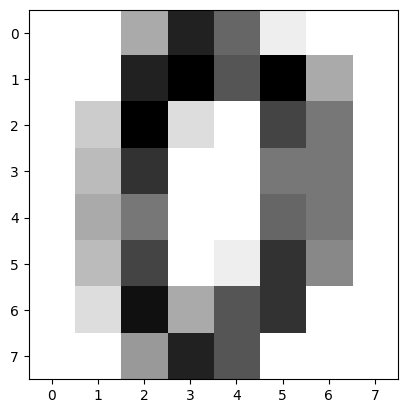

In [ ]:
from sklearn import datasets
# load the data
digits = datasets.load_digits()
images = digits.images
targets = digits.target
print("shape of image object", images.shape)
print("shape of target object", targets.shape)
# view a single image and its matrix representation
import matplotlib.pyplot as plt
plt.imshow(images[0], cmap=plt.cm.gray_r, interpolation="nearest")
print(images[0])

In [ ]:
even_id = (targets % 2 == 0)
print(even_id)

[ True False  True ...  True False  True]


In [ ]:
even_images = images[even_id]
even_targets = targets[even_id]

print("shape of even image object", even_images.shape)
print("shape of even target object", even_targets.shape)

shape of even image object (891, 8, 8)
shape of even target object (891,)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

# Reshape the even_images to a 2D array (samples, features)
# Each 8x8 image becomes a 64-feature vector
n_samples = even_images.shape[0]
data_2d = even_images.reshape((n_samples, -1))

# -------------------------------------------------------------------
# Train a KNN classifier with the prepared even digits data
# -------------------------------------------------------------------
# Parameters:
# n_neighbors=3 → classification depends on the closest 3 neighbors
# p=1 → Manhattan distance metric (L1 norm)
clf = KNeighborsClassifier(n_neighbors=3, p=1).fit(data_2d, even_targets)

print(f"KNN Classifier trained with n_neighbors={clf.n_neighbors} and p={clf.p} (Manhattan distance).")
print(f"Number of features used: {data_2d.shape[1]}")
print(f"Number of samples used: {data_2d.shape[0]}")

# Note: The decision boundary display from the original cell is removed
# as it is designed for 2-feature classification and not applicable here.

KNN Classifier trained with n_neighbors=3 and p=1 (Manhattan distance).
Number of features used: 64
Number of samples used: 891


In [ ]:
# Calculate and print the accuracy of the model
accuracy = clf.score(data_2d, even_targets)
print(f"Accuracy of the KNN model on the even digits data: {accuracy:.4f}")

Accuracy of the KNN model on the even digits data: 0.9989


In [ ]:
# Calculate the total number of images for the digit 6
total_six_images = (even_targets == 6).sum()
print(f"Total number of images for the digit 6: {total_six_images}")

Total number of images for the digit 6: 181


In [ ]:
# Make predictions on the entire dataset
predictions = clf.predict(data_2d)

# Filter for digit 6 and check for correct predictions
correctly_predicted_six = ((even_targets == 6) & (predictions == 6)).sum()
print(f"Number of digit 6 images predicted correctly: {correctly_predicted_six}")

Number of digit 6 images predicted correctly: 181


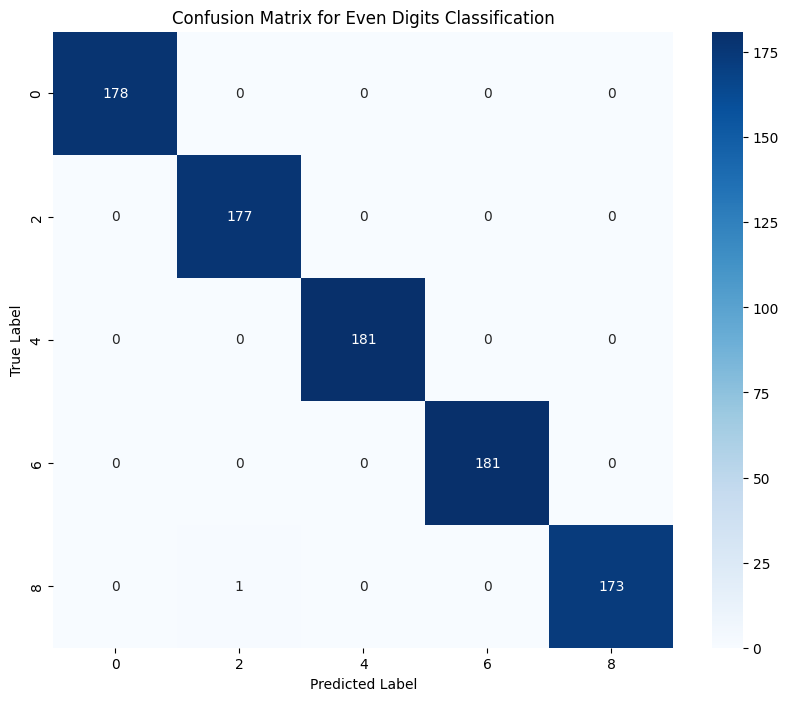

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(even_targets, predictions)

# Get the unique even target labels to use for axis labels
labels = sorted(list(set(even_targets)))

# Plot the confusion matrix as a heatmap
fig = plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Even Digits Classification')
plt.show()